# 周末定价策略回测 V3 (修正版)

## 策略说明
- **交易时间**: 周六 00:00-06:00 北京时间
- **参照物选择**: `max(hour_0, hour_6)` - 选择0点和6点USDCNH的较大值
- **交易量**: USD 60M/周, JPY 4B/周

## 重要修正
- Bloomberg JPYCNH 报价是 **每100日元** (如 4.83 = 100 JPY → 4.83 CNH)
- PnL公式: `avg_pnl(bps) × 0.0001 × 4B JPY × (JPYCNH/100)`

In [1]:
# 导入必要的库
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import os
import sys
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('ggplot')

# 设置显示选项
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("库导入完成!")

库导入完成!


In [2]:
# 配置参数
OUTPUT_DIR = r"c:\Users\tencentren\CodeBuddy\FX_SYSTEM\bmad-quant-system\output"

# 交易参数
USD_WEEKLY_VOLUME = 60_000_000      # 每周 6000万 USD
JPY_WEEKLY_VOLUME = 4_000_000_000   # 每周 40亿 JPY

print("="*60)
print("周末定价策略回测 V3 (修正版)")
print("="*60)
print(f"USD 每周交易量: {USD_WEEKLY_VOLUME:,.0f} USD")
print(f"JPY 每周交易量: {JPY_WEEKLY_VOLUME:,.0f} JPY")
print("\n*** 重要: JPYCNH 报价是每100日元 ***")

周末定价策略回测 V3 (修正版)
USD 每周交易量: 60,000,000 USD
JPY 每周交易量: 4,000,000,000 JPY

*** 重要: JPYCNH 报价是每100日元 ***


## 1. 加载数据

In [3]:
def load_data():
    """加载JPYCNH和USDCNH数据"""
    all_files = os.listdir(OUTPUT_DIR)
    
    # 找JPYCNH文件 (优先1year文件)
    jpycnh_files = [f for f in all_files if 'JPYCNH' in f and f.endswith('.xlsx') and not f.startswith('~$')]
    jpycnh_1year = [f for f in jpycnh_files if '1year' in f.lower()]
    if jpycnh_1year:
        jpycnh_files = jpycnh_1year
    
    # 找USDCNH文件
    usdcnh_files = [f for f in all_files if 'USDCNH' in f and f.endswith('.xlsx') and not f.startswith('~$')]
    usdcnh_1year = [f for f in usdcnh_files if '1year' in f.lower()]
    if usdcnh_1year:
        usdcnh_files = usdcnh_1year
    
    # 按修改时间排序
    jpycnh_files.sort(key=lambda x: os.path.getmtime(os.path.join(OUTPUT_DIR, x)), reverse=True)
    usdcnh_files.sort(key=lambda x: os.path.getmtime(os.path.join(OUTPUT_DIR, x)), reverse=True)
    
    print(f"加载 JPYCNH: {jpycnh_files[0]}")
    df_jpycnh = pd.read_excel(os.path.join(OUTPUT_DIR, jpycnh_files[0]))
    
    print(f"加载 USDCNH: {usdcnh_files[0]}")
    df_usdcnh = pd.read_excel(os.path.join(OUTPUT_DIR, usdcnh_files[0]))
    
    # 处理时间戳
    for df in [df_jpycnh, df_usdcnh]:
        if 'timestamp' in df.columns:
            df['timestamp'] = pd.to_datetime(df['timestamp'])
            df.set_index('timestamp', inplace=True)
        elif 'Unnamed: 0' in df.columns:
            df['timestamp'] = pd.to_datetime(df['Unnamed: 0'])
            df.set_index('timestamp', inplace=True)
            df.drop(columns=['Unnamed: 0'], errors='ignore', inplace=True)
    
    return df_jpycnh, df_usdcnh

# 加载数据
df_jpycnh, df_usdcnh = load_data()

print(f"\nJPYCNH 数据形状: {df_jpycnh.shape}")
print(f"USDCNH 数据形状: {df_usdcnh.shape}")
print(f"\nJPYCNH 日期范围: {df_jpycnh.index.min()} ~ {df_jpycnh.index.max()}")
print(f"USDCNH 日期范围: {df_usdcnh.index.min()} ~ {df_usdcnh.index.max()}")
print(f"\nJPYCNH 平均价格: {df_jpycnh['mid'].mean():.4f} (每100日元)")

加载 JPYCNH: JPYCNH_weekend_1year_20260130_200004.xlsx
加载 USDCNH: USDCNH_weekend_1year_20260130_195907.xlsx

JPYCNH 数据形状: (283061, 4)
USDCNH 数据形状: (283061, 4)

JPYCNH 日期范围: 2025-07-18 05:00:00 ~ 2026-01-30 18:40:00
USDCNH 日期范围: 2025-07-18 05:00:00 ~ 2026-01-30 18:40:00

JPYCNH 平均价格: 4.6708 (每100日元)


In [4]:
# 查看数据样例
print("JPYCNH 数据样例:")
display(df_jpycnh.head(10))

print("\nUSDCNH 数据样例:")
display(df_usdcnh.head(10))

JPYCNH 数据样例:


,bid,ask,spread,mid
timestamp,,,,
2025-07-18 05:00:00,4.8295,4.8387,0.0092,4.83410
2025-07-18 05:01:00,4.8290,4.8399,0.0109,4.83445
2025-07-18 05:02:00,4.8295,4.8395,0.0100,4.83450
2025-07-18 05:03:00,4.8304,4.8390,0.0086,4.83470
2025-07-18 05:04:00,4.8298,4.8387,0.0089,4.83425
2025-07-18 05:05:00,4.8311,4.8386,0.0075,4.83485
2025-07-18 05:06:00,4.8301,4.8385,0.0084,4.83430
2025-07-18 05:07:00,4.8298,4.8387,0.0089,4.83425
2025-07-18 05:08:00,4.8301,4.8386,0.0085,4.83435



USDCNH 数据样例:


,bid,ask,spread,mid
timestamp,,,,
2025-07-18 05:00:00,7.1827,7.1860,0.0033,7.18435
2025-07-18 05:01:00,7.1830,7.1866,0.0036,7.18480
2025-07-18 05:02:00,7.1820,7.1867,0.0047,7.18435
2025-07-18 05:03:00,7.1822,7.1866,0.0044,7.18440
2025-07-18 05:04:00,7.1830,7.1859,0.0029,7.18445
2025-07-18 05:05:00,7.1831,7.1852,0.0021,7.18415
2025-07-18 05:06:00,7.1830,7.1854,0.0024,7.18420
2025-07-18 05:07:00,7.1829,7.1856,0.0027,7.18425
2025-07-18 05:08:00,7.1831,7.1853,0.0022,7.18420


## 2. 准备周末数据 (周六 00:00-06:00)

In [5]:
def prepare_weekend_data(df_jpycnh, df_usdcnh):
    """准备周末数据 (周六 00:00-06:00 北京时间)"""
    df_jpycnh = df_jpycnh.copy()
    df_usdcnh = df_usdcnh.copy()
    
    # 添加时间列
    for df in [df_jpycnh, df_usdcnh]:
        df['weekday'] = df.index.dayofweek
        df['date'] = df.index.date
        df['hour'] = df.index.hour
        if 'mid' not in df.columns:
            df['mid'] = (df['bid'] + df['ask']) / 2
    
    # 筛选周六数据 (0-6点)
    jpycnh_sat = df_jpycnh[(df_jpycnh['weekday'] == 5) & (df_jpycnh['hour'] <= 6)].copy()
    usdcnh_sat = df_usdcnh[(df_usdcnh['weekday'] == 5) & (df_usdcnh['hour'] <= 6)].copy()
    
    # 获取共同日期
    common_dates = sorted(set(jpycnh_sat['date'].unique()) & set(usdcnh_sat['date'].unique()))
    
    return jpycnh_sat, usdcnh_sat, common_dates

jpycnh_sat, usdcnh_sat, common_dates = prepare_weekend_data(df_jpycnh, df_usdcnh)

print(f"JPYCNH 周六数据: {len(jpycnh_sat)} 行")
print(f"USDCNH 周六数据: {len(usdcnh_sat)} 行")
print(f"共同周六日期数: {len(common_dates)}")
print(f"日期范围: {common_dates[0]} ~ {common_dates[-1]}")

JPYCNH 周六数据: 11760 行
USDCNH 周六数据: 11760 行
共同周六日期数: 28
日期范围: 2025-07-19 ~ 2026-01-24


## 3. 回测策略

In [6]:
def backtest_strategy(jpycnh_sat, usdcnh_sat, common_dates, spread_bps=5.0):
    """
    回测周末定价策略
    
    策略: max(hour_0, hour_6) 作为USDCNH参照物
    PnL计算 (修正版): avg_pnl(bps) * 0.0001 * JPY_volume * (JPYCNH/100)
    """
    spread_half = spread_bps / 2
    adjustment_factors = [0.0, 0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.75, 1.0]
    
    results = []
    weekly_details_all = {}
    
    for adj_factor in adjustment_factors:
        weekly_details = []
        
        for sat_date in common_dates:
            jpycnh_day = jpycnh_sat[jpycnh_sat['date'] == sat_date].copy()
            usdcnh_day = usdcnh_sat[usdcnh_sat['date'] == sat_date].copy()
            
            if jpycnh_day.empty or usdcnh_day.empty:
                continue
            
            # 获取USDCNH小时参照价
            usdcnh_h0 = usdcnh_day[usdcnh_day['hour'] == 0]['mid'].mean() if len(usdcnh_day[usdcnh_day['hour'] == 0]) > 0 else np.nan
            usdcnh_h6 = usdcnh_day[usdcnh_day['hour'] == 6]['mid'].mean() if len(usdcnh_day[usdcnh_day['hour'] == 6]) > 0 else np.nan
            
            if pd.isna(usdcnh_h0) or pd.isna(usdcnh_h6):
                continue
            
            # 策略: 参照物 = max(hour_0, hour_6)
            ref_usdcnh = max(usdcnh_h0, usdcnh_h6)
            ref_used = 'hour_0' if ref_usdcnh == usdcnh_h0 else 'hour_6'
            ref_change_bps = (usdcnh_h6 - ref_usdcnh) / ref_usdcnh * 10000 if ref_usdcnh != usdcnh_h6 else 0
            
            # 对齐时间戳
            common_idx = jpycnh_day.index.intersection(usdcnh_day.index)
            if len(common_idx) < 10:
                continue
            
            jpycnh_aligned = jpycnh_day.loc[common_idx].copy()
            usdcnh_aligned = usdcnh_day.loc[common_idx].copy()
            
            jpycnh_aligned['jpycnh_ret'] = jpycnh_aligned['mid'].pct_change() * 10000
            usdcnh_aligned['usdcnh_ret'] = usdcnh_aligned['mid'].pct_change() * 10000
            
            week_pnl_bps = 0
            week_trades = 0
            week_wins = 0
            
            for i in range(1, len(common_idx)):
                ts = common_idx[i]
                usdcnh_move = usdcnh_aligned.loc[ts, 'usdcnh_ret']
                jpycnh_actual = jpycnh_aligned.loc[ts, 'jpycnh_ret']
                
                if pd.isna(usdcnh_move) or pd.isna(jpycnh_actual):
                    continue
                
                # 基于USDCNH变动预测
                predicted = (usdcnh_move + ref_change_bps * 0.01) * adj_factor
                quote_error = abs(jpycnh_actual - predicted)
                
                # PnL计算
                if quote_error < spread_half:
                    pnl = spread_half  # 赢: 赚半点差
                    week_wins += 1
                else:
                    pnl = spread_half - quote_error  # 输: (半点差 - 误差)
                
                week_pnl_bps += pnl
                week_trades += 1
            
            # 计算CNH损益 (修正版)
            jpycnh_rate_per_100jpy = jpycnh_day['mid'].mean()
            jpycnh_per_jpy = jpycnh_rate_per_100jpy / 100  # 转换为每1日元
            
            avg_pnl_per_trade_bps = week_pnl_bps / week_trades if week_trades > 0 else 0
            week_pnl_cnh = avg_pnl_per_trade_bps * 0.0001 * JPY_WEEKLY_VOLUME * jpycnh_per_jpy
            
            weekly_details.append({
                'date': sat_date,
                'trades': week_trades,
                'wins': week_wins,
                'win_rate': week_wins / week_trades if week_trades > 0 else 0,
                'avg_pnl_bps': avg_pnl_per_trade_bps,
                'jpycnh_per_jpy': jpycnh_per_jpy,
                'week_pnl_cnh': week_pnl_cnh,
                'ref_used': ref_used,
            })
        
        # 汇总结果
        if weekly_details:
            total_trades = sum(w['trades'] for w in weekly_details)
            total_wins = sum(w['wins'] for w in weekly_details)
            total_pnl_cnh = sum(w['week_pnl_cnh'] for w in weekly_details)
            
            results.append({
                'spread_bps': spread_bps,
                'adj_factor': adj_factor,
                'num_weeks': len(weekly_details),
                'total_trades': total_trades,
                'win_rate': total_wins / total_trades if total_trades > 0 else 0,
                'total_pnl_cnh': total_pnl_cnh,
                'avg_weekly_pnl_cnh': total_pnl_cnh / len(weekly_details),
            })
            weekly_details_all[adj_factor] = weekly_details
    
    df_results = pd.DataFrame(results)
    best_idx = df_results['total_pnl_cnh'].idxmax()
    best_factor = df_results.loc[best_idx, 'adj_factor']
    df_weekly = pd.DataFrame(weekly_details_all.get(best_factor, []))
    
    return df_results, df_weekly

In [7]:
# 运行不同点差的回测
spreads = [3.0, 5.0, 7.0, 10.0]
all_results = {}
df_weekly_best = None

for spread in spreads:
    print(f"\n{'='*60}")
    print(f"运行回测: 点差 = {spread} bps")
    print(f"{'='*60}")
    
    df_results, df_weekly = backtest_strategy(jpycnh_sat, usdcnh_sat, common_dates, spread_bps=spread)
    all_results[spread] = df_results
    
    # 显示最优结果
    best_idx = df_results['total_pnl_cnh'].idxmax()
    best = df_results.loc[best_idx]
    
    print(f"\n最优 Adjustment Factor: {best['adj_factor']:.2f}")
    print(f"  周数: {best['num_weeks']:.0f}")
    print(f"  胜率: {best['win_rate']*100:.1f}%")
    print(f"  总PnL: {best['total_pnl_cnh']:,.2f} CNH")
    print(f"  每周平均: {best['avg_weekly_pnl_cnh']:,.2f} CNH")
    
    if df_weekly_best is None or len(df_weekly) > len(df_weekly_best):
        df_weekly_best = df_weekly


运行回测: 点差 = 3.0 bps

最优 Adjustment Factor: 0.00
  周数: 28
  胜率: 92.9%
  总PnL: 692,662.49 CNH
  每周平均: 24,737.95 CNH

运行回测: 点差 = 5.0 bps

最优 Adjustment Factor: 0.00
  周数: 28
  胜率: 97.9%
  总PnL: 1,264,866.52 CNH
  每周平均: 45,173.80 CNH

运行回测: 点差 = 7.0 bps

最优 Adjustment Factor: 0.00
  周数: 28
  胜率: 99.1%
  总PnL: 1,806,565.09 CNH
  每周平均: 64,520.18 CNH

运行回测: 点差 = 10.0 bps

最优 Adjustment Factor: 0.00
  周数: 28
  胜率: 99.6%
  总PnL: 2,601,466.74 CNH
  每周平均: 92,909.53 CNH


## 4. 结果汇总

In [8]:
# 汇总表格
summary_rows = []
for spread, df in all_results.items():
    best_idx = df['total_pnl_cnh'].idxmax()
    best = df.loc[best_idx]
    summary_rows.append({
        '点差 (bps)': spread,
        '最优Factor': best['adj_factor'],
        '周数': best['num_weeks'],
        '胜率 (%)': f"{best['win_rate']*100:.1f}%",
        '总PnL (CNH)': f"{best['total_pnl_cnh']:,.0f}",
        '每周平均 (CNH)': f"{best['avg_weekly_pnl_cnh']:,.0f}",
        '年化 (CNH)': f"{best['avg_weekly_pnl_cnh']*52:,.0f}",
    })

df_summary = pd.DataFrame(summary_rows)
print("\n" + "="*80)
print("回测结果汇总 (修正版)")
print("="*80)
display(df_summary)


回测结果汇总 (修正版)


,点差 (bps),最优Factor,周数,胜率 (%),总PnL (CNH),每周平均 (CNH),年化 (CNH)
0,3.0,0.0,28.0,92.9%,"692,662","24,738","1,286,373"
1,5.0,0.0,28.0,97.9%,"1,264,867","45,174","2,349,038"
2,7.0,0.0,28.0,99.1%,"1,806,565","64,520","3,355,049"
3,10.0,0.0,28.0,99.6%,"2,601,467","92,910","4,831,295"


In [9]:
# 每周详细数据
print("\n每周详细数据 (最优策略):")
display(df_weekly_best)


每周详细数据 (最优策略):


,date,trades,wins,win_rate,avg_pnl_bps,jpycnh_per_jpy,week_pnl_cnh,ref_used
0,2025-07-19,419,403,0.961814,1.423129,0.048262,27473.282070,hour_6
1,2025-07-26,419,410,0.978520,1.457704,0.048536,28300.543083,hour_0
2,2025-08-02,419,361,0.861575,1.147053,0.048744,22364.891674,hour_0
3,2025-08-09,419,403,0.961814,1.427655,0.048657,27786.284856,hour_6
4,2025-08-16,419,410,0.978520,1.453811,0.048835,28398.837196,hour_6
5,2025-08-23,419,381,0.909308,1.324210,0.048846,25872.697014,hour_0
6,2025-08-30,419,412,0.983294,1.465038,0.048451,28393.305354,hour_6
7,2025-09-06,419,396,0.945107,1.391077,0.048367,26912.907797,hour_6
8,2025-09-13,419,408,0.973747,1.450786,0.048259,28005.268743,hour_0
9,2025-09-20,419,410,0.978520,1.459576,0.048117,28091.916243,hour_6


## 5. 可视化

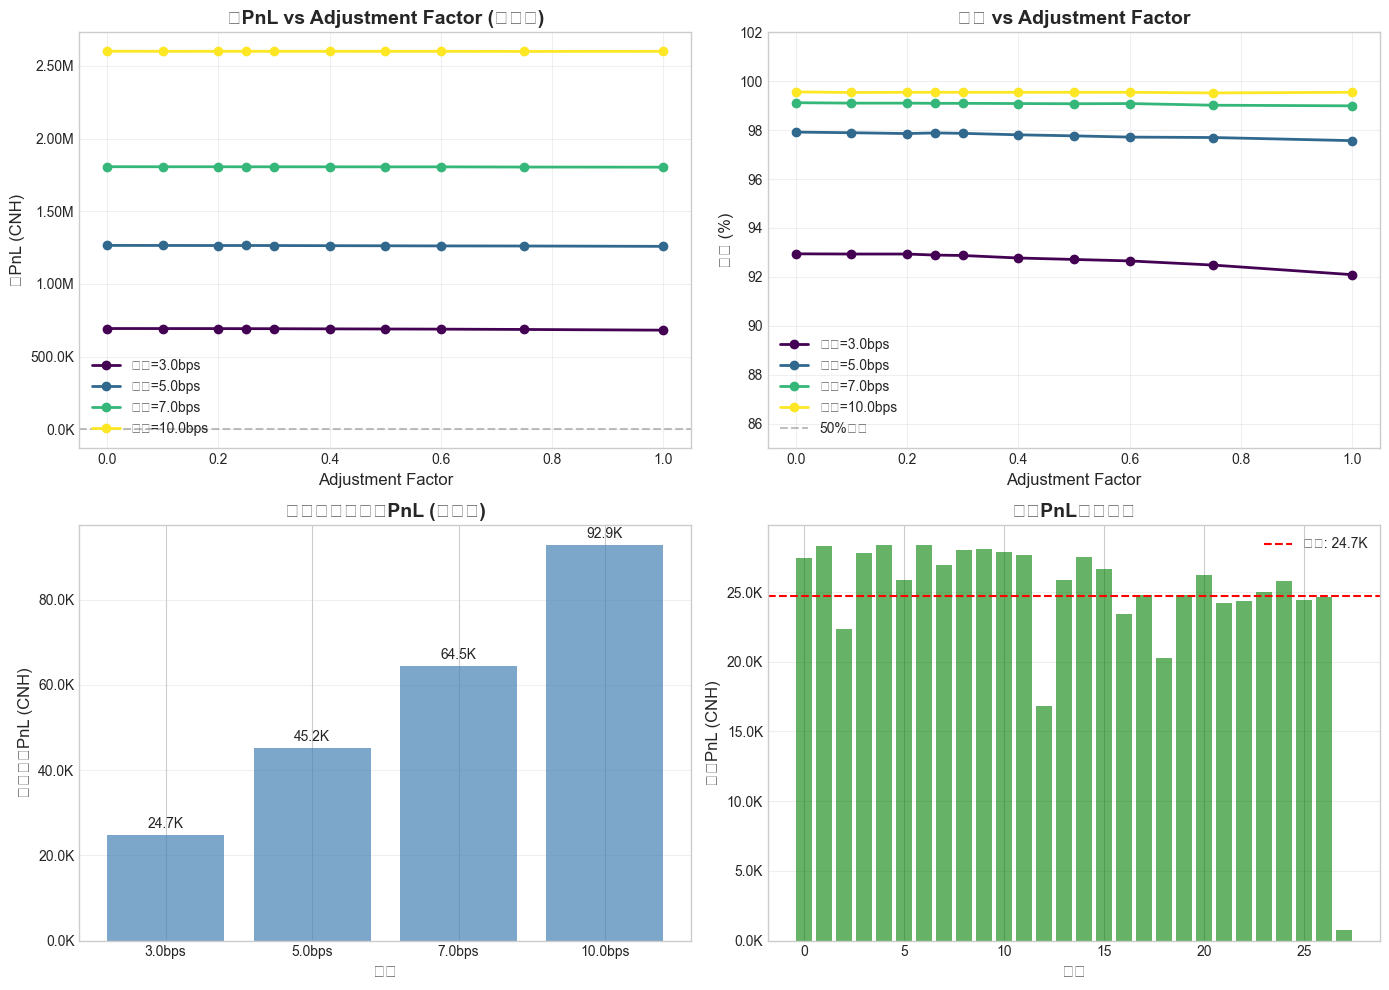

In [10]:
# 绘制回测结果
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors = plt.cm.viridis(np.linspace(0, 1, len(all_results)))

# 1. Total PnL vs Adjustment Factor
ax1 = axes[0, 0]
for i, (spread, df) in enumerate(all_results.items()):
    ax1.plot(df['adj_factor'], df['total_pnl_cnh'], 
            marker='o', linewidth=2, markersize=6, color=colors[i],
            label=f'点差={spread}bps')
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('Adjustment Factor', fontsize=12)
ax1.set_ylabel('总PnL (CNH)', fontsize=12)
ax1.set_title('总PnL vs Adjustment Factor (修正版)', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.2f}M' if abs(x) >= 1e6 else f'{x/1e3:.1f}K'))

# 2. Win Rate vs Adjustment Factor
ax2 = axes[0, 1]
for i, (spread, df) in enumerate(all_results.items()):
    ax2.plot(df['adj_factor'], df['win_rate'] * 100, 
            marker='o', linewidth=2, markersize=6, color=colors[i],
            label=f'点差={spread}bps')
ax2.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='50%基线')
ax2.set_xlabel('Adjustment Factor', fontsize=12)
ax2.set_ylabel('胜率 (%)', fontsize=12)
ax2.set_title('胜率 vs Adjustment Factor', fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([85, 102])

# 3. Average Weekly PnL by Spread
ax3 = axes[1, 0]
best_pnls = []
spreads_list = []
for spread, df in all_results.items():
    best_idx = df['total_pnl_cnh'].idxmax()
    best_pnls.append(df.loc[best_idx, 'avg_weekly_pnl_cnh'])
    spreads_list.append(spread)

bars = ax3.bar(range(len(spreads_list)), best_pnls, color='steelblue', alpha=0.7)
ax3.set_xticks(range(len(spreads_list)))
ax3.set_xticklabels([f'{s}bps' for s in spreads_list])
ax3.set_xlabel('点差', fontsize=12)
ax3.set_ylabel('每周平均PnL (CNH)', fontsize=12)
ax3.set_title('各点差最优每周PnL (修正版)', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e3:.1f}K'))

for i, pnl in enumerate(best_pnls):
    ax3.annotate(f'{pnl/1e3:.1f}K', xy=(i, pnl), xytext=(0, 5), 
                textcoords='offset points', ha='center', fontsize=10)

# 4. Weekly PnL Time Series
ax4 = axes[1, 1]
if df_weekly_best is not None and not df_weekly_best.empty:
    ax4.bar(range(len(df_weekly_best)), df_weekly_best['week_pnl_cnh'], 
           color='green', alpha=0.6)
    ax4.axhline(y=df_weekly_best['week_pnl_cnh'].mean(), color='red', 
               linestyle='--', label=f'平均: {df_weekly_best["week_pnl_cnh"].mean()/1e3:.1f}K')
    ax4.set_xlabel('周数', fontsize=12)
    ax4.set_ylabel('每周PnL (CNH)', fontsize=12)
    ax4.set_title('每周PnL时间序列', fontsize=14, fontweight='bold')
    ax4.legend(loc='best')
    ax4.grid(True, alpha=0.3, axis='y')
    ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e3:.1f}K'))

plt.tight_layout()
plt.show()

## 6. 最终结论

In [11]:
print("\n" + "="*80)
print("最终结论 - CNH损益 (修正版)")
print("="*80)

print(f"\n交易量:")
print(f"  USD: {USD_WEEKLY_VOLUME/1e6:.0f} million USD / 周")
print(f"  JPY: {JPY_WEEKLY_VOLUME/1e9:.0f} billion JPY / 周")

print(f"\n重要: Bloomberg JPYCNH 报价是每100日元")
print(f"PnL公式: avg_pnl(bps) × 0.0001 × 4B JPY × (JPYCNH/100)")

print(f"\n各点差最优结果:")
print("-"*80)
print(f"{'点差':>10} {'Factor':>10} {'胜率':>10} {'周数':>8} {'总PnL':>15} {'每周平均':>15} {'年化':>15}")
print("-"*80)

for spread, df in all_results.items():
    best_idx = df['total_pnl_cnh'].idxmax()
    best = df.loc[best_idx]
    annual = best['avg_weekly_pnl_cnh'] * 52
    print(f"{spread:>10.0f} {best['adj_factor']:>10.2f} {best['win_rate']*100:>9.1f}% {best['num_weeks']:>8.0f} {best['total_pnl_cnh']:>15,.0f} {best['avg_weekly_pnl_cnh']:>15,.0f} {annual:>15,.0f}")

print("-"*80)
print("\n年化估算 (52周):")
for spread, df in all_results.items():
    best_idx = df['total_pnl_cnh'].idxmax()
    best = df.loc[best_idx]
    annual = best['avg_weekly_pnl_cnh'] * 52
    print(f"  点差 {spread:.0f}bps: ~{annual:,.0f} CNH/年 ({annual/1e6:.2f}M CNH)")


最终结论 - CNH损益 (修正版)

交易量:
  USD: 60 million USD / 周
  JPY: 4 billion JPY / 周

重要: Bloomberg JPYCNH 报价是每100日元
PnL公式: avg_pnl(bps) × 0.0001 × 4B JPY × (JPYCNH/100)

各点差最优结果:
--------------------------------------------------------------------------------
        点差     Factor         胜率       周数            总PnL            每周平均              年化
--------------------------------------------------------------------------------
         3       0.00      92.9%       28         692,662          24,738       1,286,373
         5       0.00      97.9%       28       1,264,867          45,174       2,349,038
         7       0.00      99.1%       28       1,806,565          64,520       3,355,049
        10       0.00      99.6%       28       2,601,467          92,910       4,831,295
--------------------------------------------------------------------------------

年化估算 (52周):
  点差 3bps: ~1,286,373 CNH/年 (1.29M CNH)
  点差 5bps: ~2,349,038 CNH/年 (2.35M CNH)
  点差 7bps: ~3,355,049 CNH/年 (3.36M CNH)
  

## 7. 保存结果

In [12]:
# 保存到Excel
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
output_file = os.path.join(OUTPUT_DIR, f'weekend_backtest_notebook_{timestamp}.xlsx')

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    df_summary.to_excel(writer, sheet_name='Summary', index=False)
    for spread, df in all_results.items():
        df.to_excel(writer, sheet_name=f'Spread_{int(spread)}bps', index=False)
    if df_weekly_best is not None:
        df_weekly_best.to_excel(writer, sheet_name='Weekly_Detail', index=False)

print(f"\n结果已保存到: {output_file}")


结果已保存到: c:\Users\tencentren\CodeBuddy\FX_SYSTEM\bmad-quant-system\output\weekend_backtest_notebook_20260202_085817.xlsx
